In [1]:
import numpy as np
import matplotlib.pyplot as plt


/Users/jacky/miniconda3/envs/QMDriver/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/jacky/miniconda3/envs/QMDriver/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/jacky/miniconda3/envs/QMDriver/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/jacky/miniconda3/envs/QMDriver/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 25818 (\N{CJK UNIFIED IDEOGRAPH-64DA}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/jacky/miniconda3/envs/QMDriver/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 21547 (\N{CJK UNIFIED IDEOGRAPH-542B}) missing 

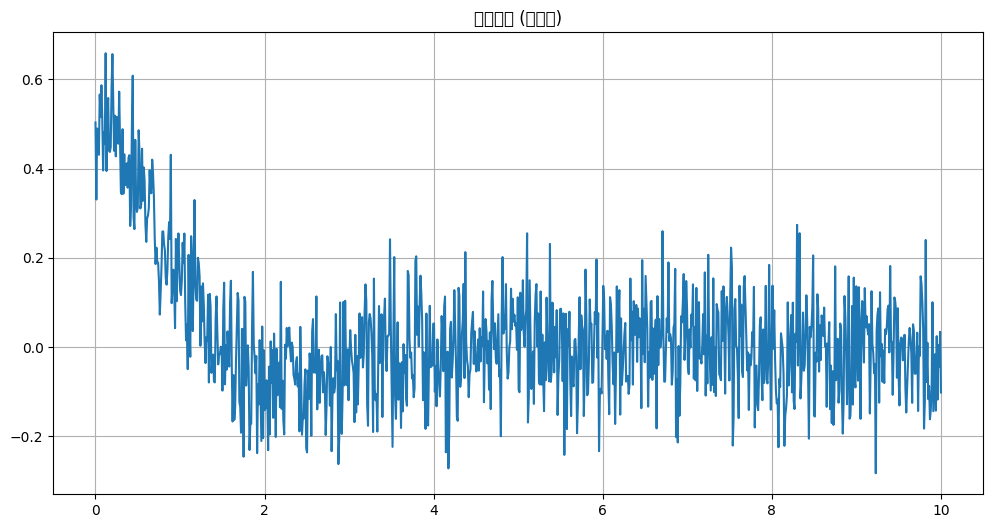

In [2]:
# 1. 模擬數據：兩個阻尼正弦波的疊加 + 噪聲
# 模型: A * exp(-kappa*t) * cos(w*t)
t = np.linspace(0, 10, 1000)
signal = 1.0 * np.exp(-1 * t) * np.cos(1 * t) + \
         -0.5 * np.exp(-2 * t)
# 加入一些噪聲
noise = 0.1 * np.random.normal(size=len(t))
data = signal + noise



# 4. 畫圖 (時頻圖 / Scalogram)
plt.figure(figsize=(12, 6))

# 上圖：原始訊號
plt.subplot()
plt.plot(t, data)
plt.title("原始數據 (含噪聲)")
plt.grid(True)

In [3]:

import pywt

# 2. 設定小波分析參數
# 我們使用 'cmor1.5-1.0' (Complex Morlet)，這是分析振盪訊號的神器
# 頻率範圍 (Scale) 需要根據你的數據採樣率調整
scales = np.arange(1, 128) 
coeffs, freqs = pywt.cwt(data, scales, 'cmor1.5-1.0', sampling_period=t[1]-t[0])

# 3. 計算能量 (Power) = 模值的平方
power = (abs(coeffs)) ** 2

# 4. 畫圖 (時頻圖 / Scalogram)
plt.figure(figsize=(12, 6))


# 下圖：小波時頻圖
plt.subplot()
# 使用 contourf 畫出能量分佈
plt.contourf(t, freqs, power, levels=50, cmap='jet')
plt.ylabel('頻率 (Hz)')
plt.xlabel('時間 (s)')
plt.title('小波時頻圖 (Magnitude Squared)')
plt.colorbar(label='能量強度')

# 標示出預期的真實頻率
plt.axhline(5, color='w', linestyle='--', alpha=0.5, label='True 5Hz')
plt.axhline(3, color='w', linestyle='--', alpha=0.5, label='True 3Hz')
plt.legend()

plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'pywt'

/var/folders/gj/5g2p36y973q8qh7rskmqbpp00000gn/T/ipykernel_20996/825165332.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


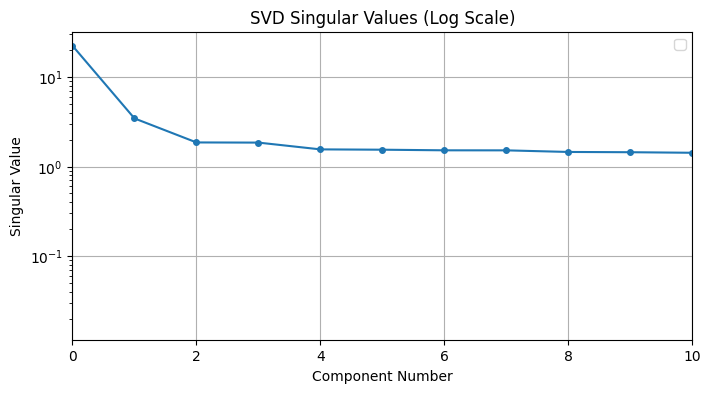

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd, hankel


# 2. 構建 Hankel 矩陣
# 矩陣大小通常取 N/2 x N/2 或類似比例
c = data[0:100]
r = data[99:199]
H = hankel(c, r)

# 3. SVD 分解
U, S, Vh = svd(H)


# 4. 畫出奇異值
plt.figure(figsize=(8, 4))
plt.plot(S, 'o-', markersize=4)
plt.yscale('log')
plt.title('SVD Singular Values (Log Scale)')
plt.xlabel('Component Number')
plt.ylabel('Singular Value')
plt.grid(True)
plt.xlim(0, 10)

# 理論上：
# 震盪成分 (cos) 需要 2 個特徵值 (秩=2)
# 純衰減成分 (exp) 需要 1 個特徵值 (秩=1)
# 所以你應該會看到 3 個大的數值，第 4 個開始驟降 (噪聲基底)
# plt.axvline(2.5, color='r', linestyle='--', label='Expected Cutoff (3 components)')
plt.legend()
plt.show()

In [29]:
import numpy as np
import scipy.linalg as la

def hlsvd_estimate(data, dt, n_components):
    """
    使用 Hankel-SVD (類 ESPRIT) 方法估計頻率與衰減
    data: 1D 訊號數組
    dt: 採樣間隔
    n_components: 你決定的組件數量 (K值)
    """
    N = len(data)
    L = N // 2  # Hankel 矩陣維度
    
    # 1. 構建 Hankel 矩陣
    H = la.hankel(data[:L], data[L-1:])
    
    # 2. SVD 分解
    U, S, Vh = la.svd(H, full_matrices=False)
    
    # 3. 截斷 SVD (只保留前 K 個大的奇異值對應的向量)
    Uk = U[:, :n_components]
    
    # 4. 利用旋轉不變性 (Shift Invariance) 求解特徵值
    # 這是 ESPRIT/HSVD 的核心魔法
    U_up = Uk[:-1, :]   # 上半部分
    U_down = Uk[1:, :]  # 下半部分
    
    # 解線性方程 U_up * Phi = U_down，求矩陣 Phi
    Phi, _, _, _ = la.lstsq(U_up, U_down)
    
    # 5. 計算 Phi 的特徵值 (這些就是訊號極點 z)
    z_poles = la.eigvals(Phi)
    
    # 6. 將 z 轉換回物理參數 (Freq, Decay)
    # z = exp((-k + jw)*dt)
    
    results = []
    for z in z_poles:
        # 排除數值誤差導致的極微小 z (避免 log(0))
        if np.abs(z) < 1e-10: continue
            
        kappa = -np.log(np.abs(z)) / dt
        w = np.angle(z) / dt
        freq_hz = w / (2 * np.pi)
        
        # 過濾掉負頻率 (因為共軛對會產生正負頻率，物理上我們只看正的)
        if freq_hz >= -1e-5: 
            results.append({"Freq_Hz": freq_hz, "Decay_k": kappa, "Is_Oscillating": freq_hz > 1e-4})
            
    return results

# --- 測試案例 ---
t = np.linspace(0, 2, 200)
dt = t[1] - t[0]

# 模擬信號：
# 1. 5Hz 震盪 (Rank=2)
# 2. 純衰減 k=3 (Rank=1, Freq=0)
clean_sig = 1.0 * np.exp(-1*t) * np.cos(2*np.pi*5*t) + \
            0.5 * np.exp(-3*t)

# 加上一點噪聲
data = clean_sig + 0.1 * np.random.randn(len(t))

# 假設我們通過觀察奇異值，決定使用 K=3 (2個震盪 + 1個衰減)
estimated_params = hlsvd_estimate(data, dt, n_components=3)

print(f"{'類型':^10} | {'頻率 (Hz)':^12} | {'衰減率 (k)':^12}")
print("-" * 40)
for res in estimated_params:
    etype = "震盪" if res['Is_Oscillating'] else "純衰減"
    print(f"{etype:^10} | {res['Freq_Hz']:^12.4f} | {res['Decay_k']:^12.4f}")

    類型     |   頻率 (Hz)    |   衰減率 (k)   
----------------------------------------
    震盪     |    5.0101    |    0.9179   
   純衰減     |    0.0000    |    3.0338   


觀察圖表：
1. 真實頻率 (5Hz, 12Hz) 會形成垂直的『直線』。
2. 噪聲導致的假頻率會散落在周圍，且隨著 K 改變而移動。


c:\Users\shiau\miniconda3\envs\qcat\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31337 (\N{CJK UNIFIED IDEOGRAPH-7A69}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\shiau\miniconda3\envs\qcat\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23450 (\N{CJK UNIFIED IDEOGRAPH-5B9A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\shiau\miniconda3\envs\qcat\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


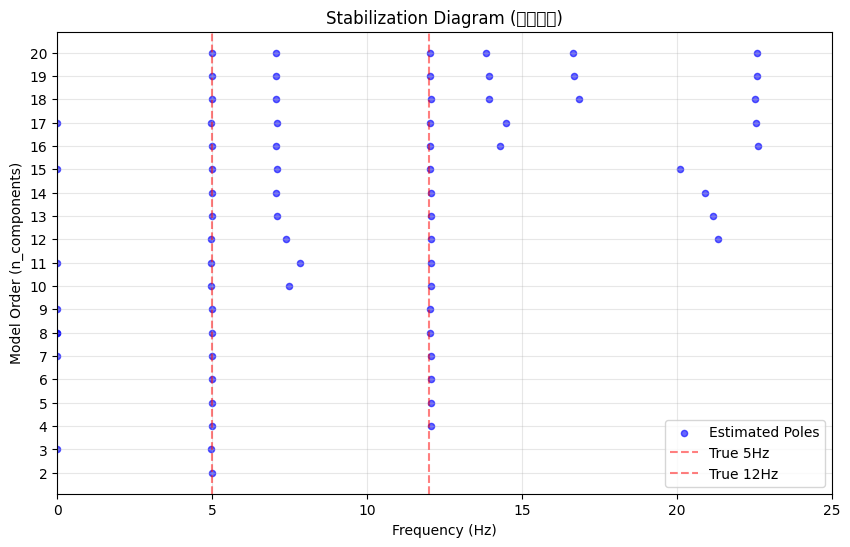

In [30]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

# --- 1. 準備工具函數 (與之前相同，簡化版) ---
def get_poles(data, dt, n_comp):
    """給定 K (n_comp)，回傳算出的所有頻率"""
    N = len(data)
    L = N // 2
    H = la.hankel(data[:L], data[L-1:])
    U, S, Vh = la.svd(H, full_matrices=False)
    
    Uk = U[:, :n_comp]
    U_up = Uk[:-1, :]
    U_down = Uk[1:, :]
    
    Phi, _, _, _ = la.lstsq(U_up, U_down)
    z_poles = la.eigvals(Phi)
    
    freqs = []
    for z in z_poles:
        # 過濾數值誤差
        if np.abs(z) < 1e-5: continue
        w = np.angle(z) / dt
        f = w / (2 * np.pi)
        if f >= 0: freqs.append(f)
    return freqs

# --- 2. 模擬數據 ---
t = np.linspace(0, 2, 200)
dt = t[1] - t[0]

# 真實訊號：只有 2 個成分 (5Hz 和 12Hz)
# 注意：我加了很大的噪聲，讓判斷變難
true_freqs = [5.0, 12.0]
signal = 1.0 * np.exp(-0.5*t) * np.cos(2*np.pi*5*t) + \
         0.8 * np.exp(-0.8*t) * np.cos(2*np.pi*12*t)
noise = 0.5 * np.random.randn(len(t)) # 噪聲很大！
data = signal + noise

# --- 3. 穩定性分析 (掃描 K=2 到 K=20) ---
k_values = range(2, 21)
all_freqs = []
all_k = []

for k in k_values:
    fs = get_poles(data, dt, n_comp=k)
    # 將結果存起來
    for f in fs:
        all_freqs.append(f)
        all_k.append(k)

# --- 4. 畫圖 ---
plt.figure(figsize=(10, 6))

# 畫出每次算出來的頻率點
plt.scatter(all_freqs, all_k, c='blue', s=20, alpha=0.6, label='Estimated Poles')

# 標示真實頻率
plt.axvline(5.0, color='r', linestyle='--', alpha=0.5, label='True 5Hz')
plt.axvline(12.0, color='r', linestyle='--', alpha=0.5, label='True 12Hz')

plt.title('Stabilization Diagram (穩定性圖)')
plt.ylabel('Model Order (n_components)')
plt.xlabel('Frequency (Hz)')
plt.yticks(k_values)
plt.grid(True, alpha=0.3)
plt.xlim(0, 25) # 觀察 0-25Hz 範圍
plt.legend()

print("觀察圖表：")
print("1. 真實頻率 (5Hz, 12Hz) 會形成垂直的『直線』。")
print("2. 噪聲導致的假頻率會散落在周圍，且隨著 K 改變而移動。")
plt.show()